# 4. starfold — astronomy case study

This notebook applies the full pipeline to real Milky Way stars
from APOGEE DR19 (chemistry) joined with orbital actions derived
from `galpy` integrations of Gaia DR3 astrometry. The feature
matrix is eight columns: three chemical abundances (`fe_h`,
`alpha_m`, `mg_fe`) and five dynamical quantities (`J_R`, `J_z`,
`L_z`, `ecc`, `E`).

The *point* of this notebook is **not** to reproduce the paper's
scientific conclusions. It is to show that the same
domain-agnostic `fit(X)` call that clustered a torus chain in
notebooks 1–3 recovers recognisable chrono-chemo-kinematic
structure on a real sample. See
`docs/data/stellar_chemokinematics_apogee_dr19.provenance.md`
for how the sample was built and which surveys it derives from.

To keep the notebook cheap on a laptop the full 9 242-star sample
is subsampled to 4 000 stars. Replace the `subsample_n` line below
with `subsample_n = None` if you have RAM and time for the full run.

In [1]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "examples"))

import starfold as sf  # noqa: E402
from starfold.plotting import plot_per_cluster_credibility  # noqa: E402

FIGURE_DIR = Path("figures") / "tutorial_04_astronomy"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = Path("data") / "stellar_chemokinematics_apogee_dr19.parquet"

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"starfold {sf.__version__}")
print(f"loading  {DATA_PATH}")

starfold 0.0.1
loading  data/stellar_chemokinematics_apogee_dr19.parquet


## 4.1 Load and assemble the feature matrix

The parquet ships with the repo (~0.5 MB). Every column is `float32`,
every row is a star, and `source_id` is the Gaia DR3 identifier. No
`astropy`, no survey download, no orbit integration at notebook
time — everything the pipeline needs is in the file.

In [2]:
subsample_n = 4000
df_full = pd.read_parquet(DATA_PATH)
if subsample_n is not None and subsample_n < len(df_full):
    df = df_full.sample(n=subsample_n, random_state=0).reset_index(drop=True)
else:
    df = df_full.reset_index(drop=True)

feature_cols = ["fe_h", "alpha_m", "mg_fe", "J_R", "J_z", "L_z", "ecc", "E"]
X = df[feature_cols].to_numpy(dtype=np.float64, copy=True)
print(f"full sample : {len(df_full):,} stars")
print(f"in use      : {len(df):,} stars "
      f"(subsample_n={subsample_n})")
print(f"features    : {feature_cols}")
print(f"X.shape     : {X.shape}")
print()
print(df[feature_cols].describe().T[["mean", "std", "min", "max"]])

full sample : 9,242 stars
in use      : 4,000 stars (subsample_n=4000)
features    : ['fe_h', 'alpha_m', 'mg_fe', 'J_R', 'J_z', 'L_z', 'ecc', 'E']
X.shape     : (4000, 8)

                  mean          std            min            max
fe_h         -0.153169     0.246856      -1.751451       0.440309
alpha_m       0.072332     0.086639      -0.092843       0.393906
mg_fe         0.093744     0.104157      -0.230574       0.422216
J_R          52.165913    82.048653       0.007438    1750.494873
J_z          19.882061    28.601784       0.001617     466.047577
L_z        1803.758423   375.006348    -913.966064    2766.923340
ecc           0.172780     0.120997       0.002226       0.995891
E       -157081.593750  8776.775391 -192762.765625 -123823.976562


## 4.2 Fit the pipeline

Real data, so the noise baseline stays on (8 realisations, 2 Optuna
trials each, serial) — enough for per-cluster significance
attribution while keeping peak RAM modest. Push `n_realisations` up
on a workstation.

In [3]:
pipeline = sf.UnsupervisedPipeline(
    umap_kwargs={"n_epochs": 600, "n_neighbors": 30, "min_dist": 0.0},
    hdbscan_optuna_trials=30,
    hdbscan_objective="combined_geom",
    mcs_range=(40, 400),
    ms_range=(5, 30),
    engine="auto",
    skip_noise_baseline=False,
    random_state=0,
    noise_baseline_kwargs={
        "n_realisations": 8,
        "per_realisation_trials": 2,
        "percentile": 99.7,
        "n_jobs": 1,
        "umap_kwargs": {
            "n_neighbors": 30,
            "min_dist": 0.0,
            "n_epochs": 200,
        },
    },
)
t0 = time.perf_counter()
result = pipeline.fit(X)
print(f"pipeline.fit took {time.perf_counter() - t0:.1f}s")
print()
print(result.summary())

[2026-04-22 17:45:48.568] [CUML] [info] build_algo set to brute_force_knn because random_state is given


[2026-04-22 17:46:02.406] [CUML] [info] build_algo set to brute_force_knn because random_state is given


[2026-04-22 17:46:03.651] [CUML] [info] build_algo set to brute_force_knn because random_state is given


[2026-04-22 17:46:04.907] [CUML] [info] build_algo set to brute_force_knn because random_state is given


[2026-04-22 17:46:06.277] [CUML] [info] build_algo set to brute_force_knn because random_state is given


[2026-04-22 17:46:07.484] [CUML] [info] build_algo set to brute_force_knn because random_state is given


[2026-04-22 17:46:08.718] [CUML] [info] build_algo set to brute_force_knn because random_state is given


[2026-04-22 17:46:09.976] [CUML] [info] build_algo set to brute_force_knn because random_state is given


[2026-04-22 17:46:11.643] [CUML] [info] build_algo set to brute_force_knn because random_state is given


pipeline.fit took 31.6s

starfold pipeline result
--------------------------------
n_samples        4000
n_clusters       2
n_outliers       0  (0.0%)
trustworthiness  0.9610
continuity       0.9717
objective        combined_geom
best_params      {'min_cluster_size': 386, 'min_samples': 13, 'cluster_selection_method': 'eom', 'cluster_selection_epsilon': 0.27542890955772004, 'alpha': 0.7622930880720811}
persistence_sum  1.4604
persistence_med  0.7302
DBCV (MST proxy) 0.7577
noise_threshold  0.1988
significant      2/2
credibility      FAIL at alpha=0.003  p(n_clusters)=1.0000  p(combined_geom)=0.1111  p(max_persistence)=0.1111
per-cluster      0/2 clusters credible
persistence      [0.867 0.594]


## 4.3 Credibility check

Exactly the same omnibus 3σ test as in notebook 2. This is where
real data earns its keep: if the run doesn't clear the null on at
least *some* clusters, the downstream astronomy plots are
premature.

credibility at alpha=0.003: FAIL
  n_clusters      obs=2  null-median=2  p=1.0000
  combined_geom   obs=0.7438  null-median=0.0044  p=0.1111
  max_persistence obs=0.8666  null-median=0.0732  p=0.1111
  per-cluster     0/2 clusters credible at alpha=0.003


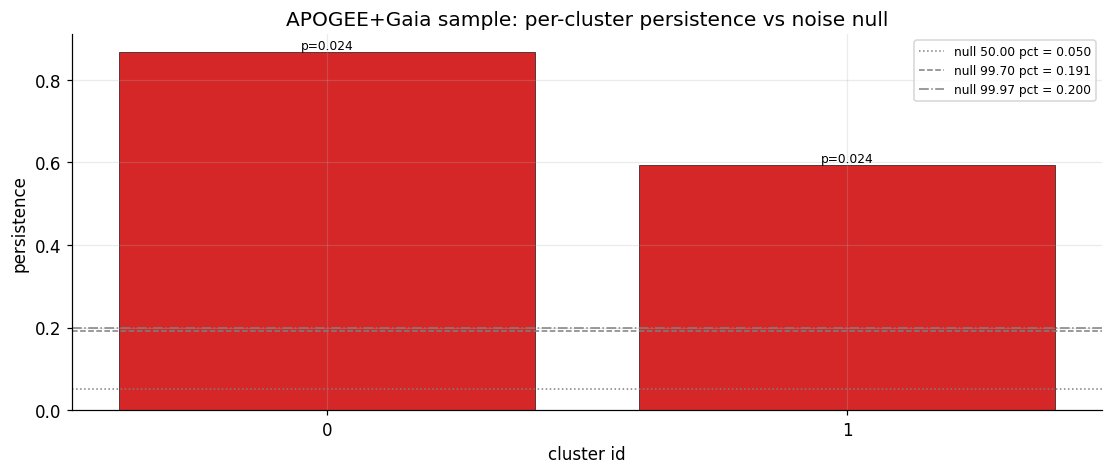

In [4]:
credibility = result.credibility
assert credibility is not None, "noise baseline was required for credibility"
print(credibility.summary())

fig, ax = plt.subplots(figsize=(10.0, 4.2), constrained_layout=True)
plot_per_cluster_credibility(credibility, ax=ax)
ax.set_title("APOGEE+Gaia sample: per-cluster persistence vs noise null")
fig.savefig(FIGURE_DIR / "01_credibility.png")
plt.show()

## 4.4 The embedding

The 2-D UMAP layout coloured by HDBSCAN label, plus a reference
map coloured by `[Fe/H]` so the chemical gradient across the
embedding is visible.

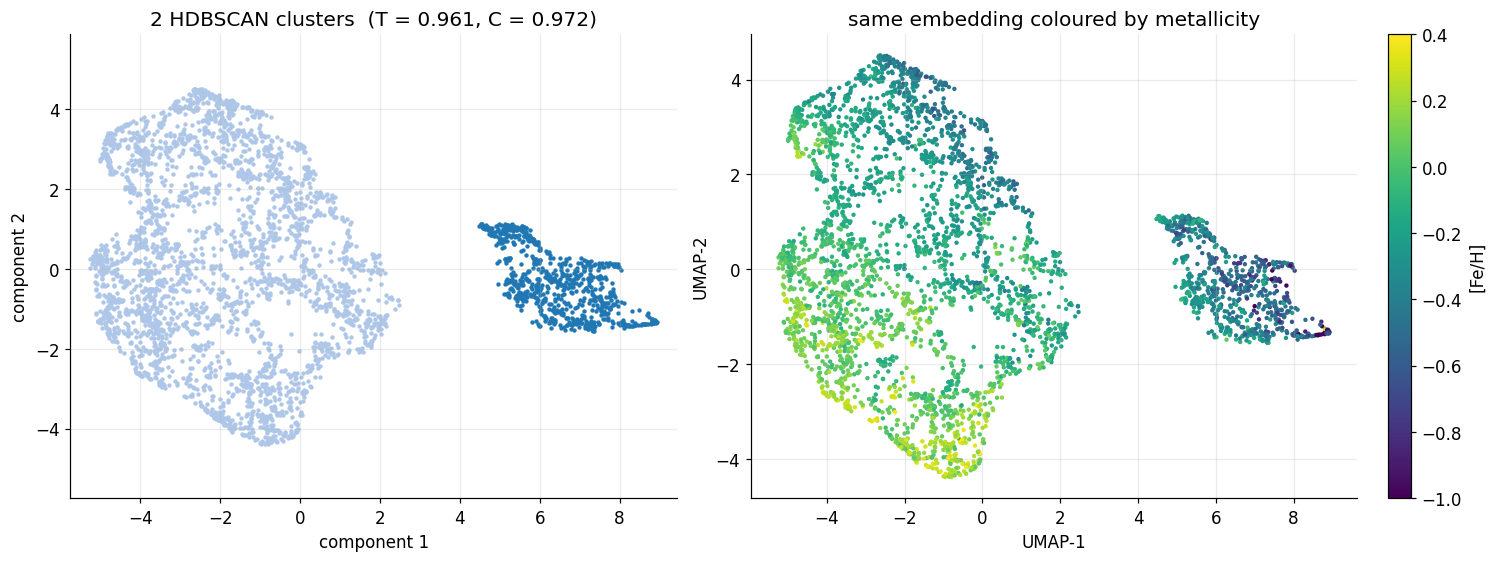

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0), constrained_layout=True)
sf.plot_embedding(result.embedding, result.labels, ax=axes[0],
                  point_size=3.5, cmap="tab20")
axes[0].set_title(
    f"{result.n_clusters} HDBSCAN clusters  "
    f"(T = {result.trustworthiness:.3f}, C = {result.continuity:.3f})"
)

sc = axes[1].scatter(
    result.embedding[:, 0], result.embedding[:, 1],
    c=df["fe_h"].to_numpy(), cmap="viridis", s=3.5, vmin=-1.0, vmax=0.4,
)
plt.colorbar(sc, ax=axes[1], label="[Fe/H]")
axes[1].set_xlabel("UMAP-1"); axes[1].set_ylabel("UMAP-2")
axes[1].set_title("same embedding coloured by metallicity")
fig.savefig(FIGURE_DIR / "02_embedding.png")
plt.show()

## 4.5 Chemical abundance plane

The $[\alpha/\mathrm{M}]$ vs $[\mathrm{Fe/H}]$ plane separates the
thin and thick discs on a chemical basis. HDBSCAN had no knowledge
of this plane — the fact that clusters separate cleanly along it is
a sanity check on the full eight-feature clustering.

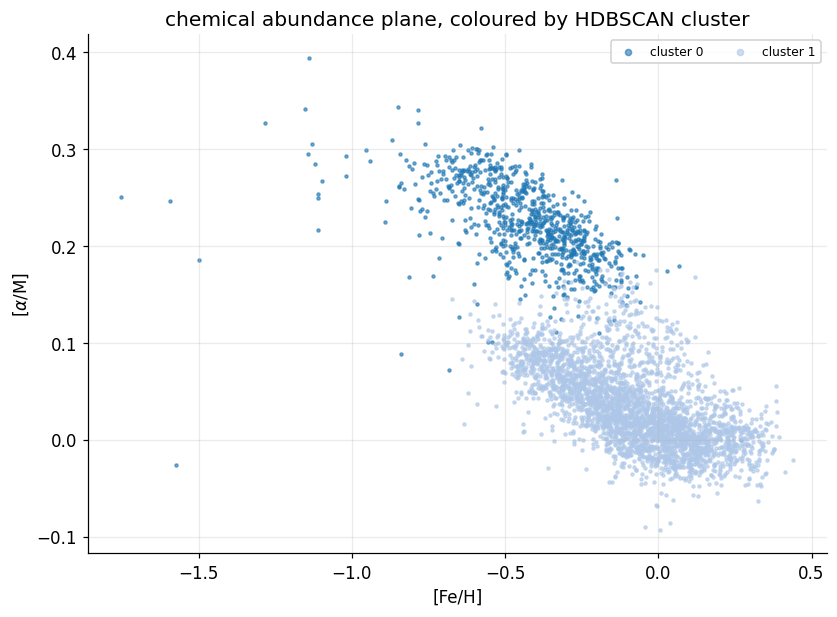

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 5.5), constrained_layout=True)
labels = result.labels
uniq = sorted({int(k) for k in labels.tolist()})
cmap = plt.get_cmap("tab20")
for k in uniq:
    m = labels == k
    colour = "lightgrey" if k == -1 else cmap(uniq.index(k) % 20)
    label = "outlier" if k == -1 else f"cluster {k}"
    ax.scatter(df.loc[m, "fe_h"], df.loc[m, "alpha_m"],
               s=4, color=colour, alpha=0.6, label=label)
ax.set_xlabel("[Fe/H]")
ax.set_ylabel(r"$[\alpha/\mathrm{M}]$")
ax.set_title("chemical abundance plane, coloured by HDBSCAN cluster")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9, ncol=2, markerscale=2)
fig.savefig(FIGURE_DIR / "03_chemical_plane.png")
plt.show()

## 4.6 Action-space diagram

A Toomre-like view of orbit kinematics: total non-circular action
$\sqrt{J_R^2 + J_z^2}$ (proxy for orbital heat) against azimuthal
action $L_z$ (proxy for rotational support). Disc stars sit low and
rightward; halo stars climb to high $\sqrt{J_R^2 + J_z^2}$ and can
reach negative $L_z$ (retrograde motion).

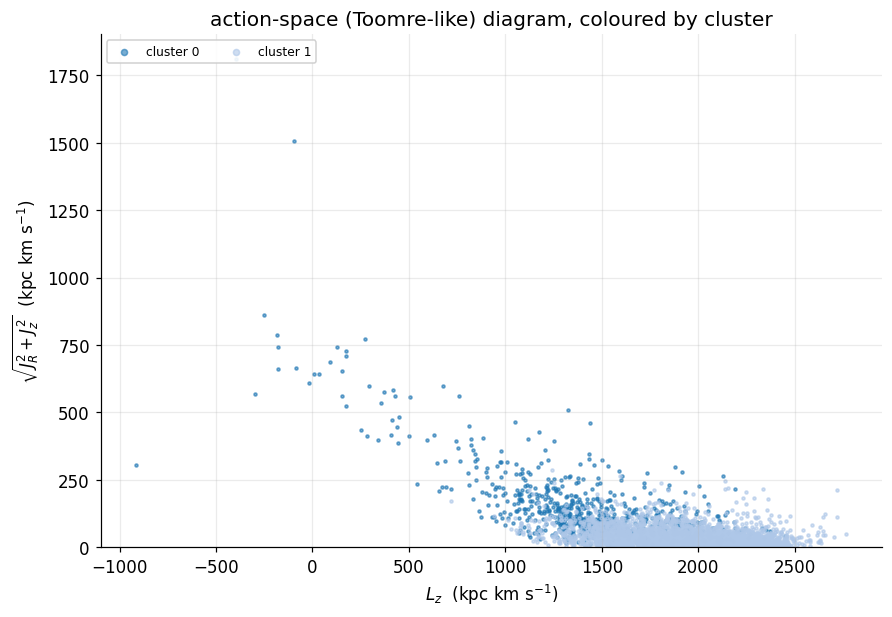

In [7]:
J_nr = np.sqrt(df["J_R"] ** 2 + df["J_z"] ** 2)
L_z = df["L_z"].to_numpy()

fig, ax = plt.subplots(figsize=(8.0, 5.5), constrained_layout=True)
for k in uniq:
    m = labels == k
    colour = "lightgrey" if k == -1 else cmap(uniq.index(k) % 20)
    label = "outlier" if k == -1 else f"cluster {k}"
    ax.scatter(L_z[m], J_nr[m], s=4, color=colour, alpha=0.6, label=label)
ax.set_xlabel(r"$L_z$  (kpc km s$^{-1}$)")
ax.set_ylabel(r"$\sqrt{J_R^2 + J_z^2}$  (kpc km s$^{-1}$)")
ax.set_title("action-space (Toomre-like) diagram, coloured by cluster")
ax.set_ylim(0, None)
ax.legend(loc="upper left", fontsize=8, framealpha=0.9, ncol=2, markerscale=2)
fig.savefig(FIGURE_DIR / "04_action_space.png")
plt.show()

## 4.7 Caveats

* The sample is a 9 242-star slice of a larger chemo-dynamical
  pipeline output (the notebook subsamples it further). Selection
  effects (APOGEE's pointing pattern, Gaia's faint-end
  incompleteness, the quality cuts described in the provenance
  file) are not modelled here.
* The paper's scientific conclusions rely on a *different* sample
  (APOGEE DR17 × astroNN) and on domain validation (VM criterion,
  orbit action priors) that `starfold` does not implement. This
  notebook is a methodology demonstrator, not a reproduction.
* Clusters that fail the per-cluster credibility test in §4.3 are
  not claims about astrophysics; they are signals the methodology
  declines to commit to.

That closes the tutorial arc: **fit → validate → refine → apply**.